# Testing OT and SCC Agreement for Multiple Resolutions
For OT at 8 Mb and no threshold and SCC at 1 Mb, the results don't agree much. To see if this is an issue with the discrepency in resolution, we will try to run OT at multiple different resolutions and threshold to get closer to 1 Mb.

## Imports

In [2]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from time import perf_counter
from pathlib import Path
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, scc_compare_matrix, bin_contact_map, fetch_region, get_cool_name, hic_ot_source_to_targets, compare_to_scc

# Data directories
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_scc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_scc_chr1'
save_ot_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_ot_chr1'

## Helper Functions

In [ ]:
def update_time_file(calc_time: int, r2: float, res: int, threshold: int, 
                     cell_type: str, cell_count: int):
    '''
        Updates the computation time csv file to keep track of
        computation times and r2 even if the kernel crashes.

        Parameters
        ----------
        calc_time : int
            Calculation time to be savedss
        r2 : float
            Calculated r2 value to be saved
        res : int
            Resolution of the OT performed
        threshold : int
            Threshold for the OT performed
        cell_type : str
            Cell type examined.
        cell_count : int
            Number of cells examined.

        Returns
        -------
        df_calc : pd.DataFrame
            Dataframe containing computation times.
        df_r2 : pd.Dataframe
            Dataafraame containing r2 values
    '''
    
    # Initialize csv path
    calc_path = f'/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/exact_{cell_type}_{cell_count}_times.csv'
    r2_path = f'/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/exact_{cell_type}_{cell_count}_r2.csv'

    # Cast to strings to ensure prope
    res = str(res)
    threshold = str(threshold)

    # Make or import csv
    if os.path.exists(calc_path):
        df_calc = pd.read_csv(calc_path, index_col=0)
        df_calc.index = df_calc.index.astype(str)
    else:
        df_calc = pd.DataFrame()

    if os.path.exists(r2_path):
        df_r2 = pd.read_csv(r2_path, index_col=0)
        df_r2.index = df_r2.index.astype(str)
    else:
        df_r2 = pd.DataFrame()

    # Create column 
    if res not in df_calc.columns:
        df_calc[res] = pd.Series(dtype="float")

    if res not in df_r2.columns:
        df_r2[res] = pd.Series(dtype="float")

    # Insert value in row
    df_calc.at[threshold, res] = calc_time

    df_r2.at[threshold, res] = r2

    # Save to CSV
    df_calc.to_csv(calc_path)

    df_r2.to_csv(r2_path)

    return df_calc, df_r2

def sc_scc_ot(res: int, thres: int, cell_type: str, cell_count: int):
    '''
        Calculates pairwise SCC scores at 1 Mb and exact OT loss for
        the specified resolution and threshold. Data takes specified
        cell type and number of cells from the sc data. Saves SCC scores
        and OT results if they had yet to be saved. Produces graph comparing
        SCC scores to OT loss.

        This function is specific to this notebook.

        Parameters
        ---------
        res : int
            Resolution of the OT calculations.
        thres : int
            Threshold for the OT calculations.
        cell_types : str
            Cell type to be used from the data.
        cell_count : int
            Number of cells to be taken from the data.

        Returns
        -------
        scc_results : pd.DataFrame
            Pandas dataframe for SCC results.
        ot_results : pd.DataFrame
            Pandas dataframe for the OT results.
        r2_value : float
            r2 value for the comparison between OT and SCC.
    '''
    # Opening data
        # Metadata
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    cell_type_metadata = metadata[metadata["cell_type"] == cell_type]
    subset = list(cell_type_metadata["cell_name"])[0:cell_count]

        # Importing dendritic cell subset
    clrs = import_cool_dir(sc_dir, include=subset)

    # SCC
        # Check if file already exists
    scc_file = f'{save_scc_dir}/{cell_type}_chr1_scc_{cell_count}.csv'
    ot_file = f'{save_ot_dir}/{cell_type}_chr1_exact_{res}mb_{thres}_{cell_count}.csv'

    if not os.path.exists(scc_file):
        # Perform SCC and save
        scc_results = scc_compare_matrix(clrs, 0, -1, False, ["chr1"])
        scc_results.to_csv(scc_file)
    else:
        # Open SCC
        scc_results = pd.read_csv(scc_file, index_col=0)

    # OT
        # Extracting chromosome 1
    chr1s = []
    map_names = []

    for clr in clrs:
        chr1s.append(fetch_region(clr, 'chr1'))
        map_names.append(get_cool_name(clr).split("_")[2])

        # Binning
    binned = []
    for chr1 in chr1s:
        binned.append(bin_contact_map(chr1, res))

        # Performing OT
    ot_results_list = []
    start_time = perf_counter()
    for map in binned:
        if thres == 0:
            ot_results_list.append(hic_ot_source_to_targets(map, binned, thres, "raw", "sum"))
        else:
            ot_results_list.append(hic_ot_source_to_targets(map, binned, thres, "percentile", "sum"))
    end_time = perf_counter()
    calc_time = end_time - start_time

    # R2 value and graph
    ot_results, r2_value = compare_to_scc(ot_results_list, map_names, scc_results,
                                               thres, res, plot = True)

    # Saving results
    ot_results.to_csv(ot_file)

    # Saving comptime and r2
    update_time_file(calc_time, r2_value, res, thres, cell_type, cell_count)

    return scc_results, ot_results, r2_value

def load_ot_results(folder: str, cell_type: str, cell_count: int):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        cell_type : str
            Cell type used for analysis.
        cell_count : int
            Number of cells used for analysis.
        
        Returns
        -------
        ot_dfs : dict
            Dictionary of ot dataframes.
            Resolution and thresholds act as keys.
    '''
    folder = Path(folder)
    
    # Storage dictionary
    ot_dfs = {}

    # Regex patterns
    ct = re.escape(str(cell_type))
    cc = re.escape(str(cell_count))

    pattern = re.compile(
        rf"^{ct}_chr1_exact_(\d+)mb_(\d+)_{cc}\.csv$"
    )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            resolution = int(m.group(1))
            threshold = int(m.group(2))
            df = pd.read_csv(file, index_col=0)
            ot_dfs[(resolution, threshold)] = df

    return ot_dfs

## 8 Mb

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

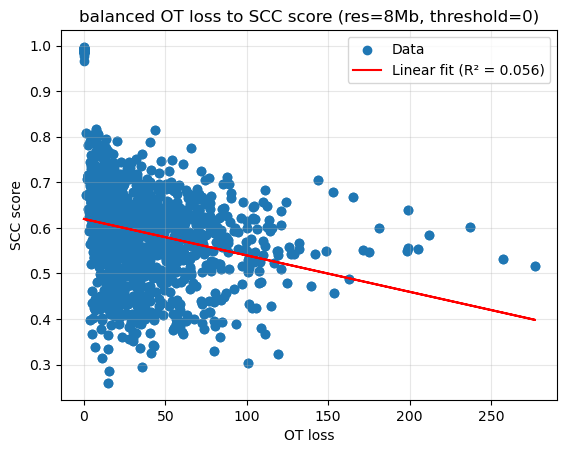

In [4]:
### 0 % Threshold ###
sc_scc_ot(8, 0, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

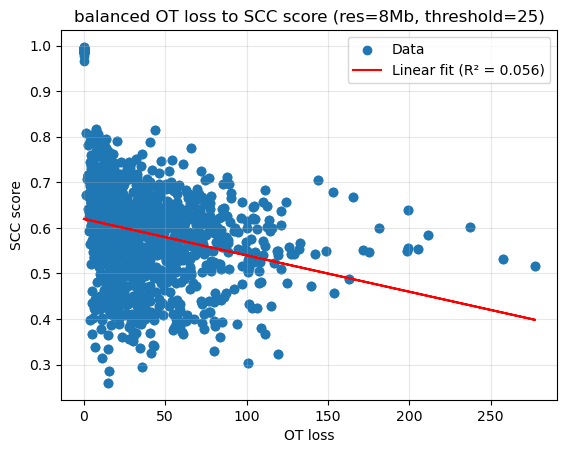

In [5]:
### 25 % Threshold ###
sc_scc_ot(8, 25, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

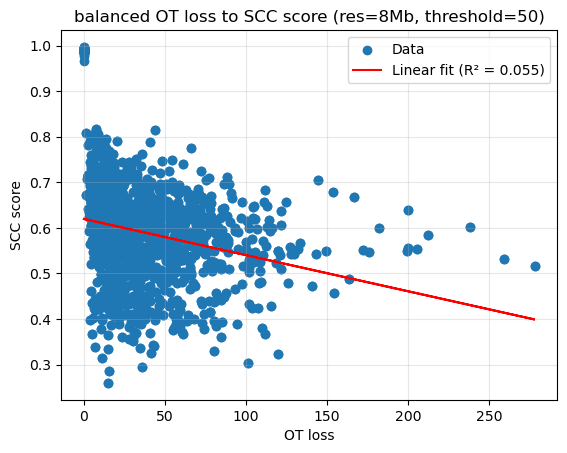

In [6]:
### 50 % Threshold ###
sc_scc_ot(8, 50, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

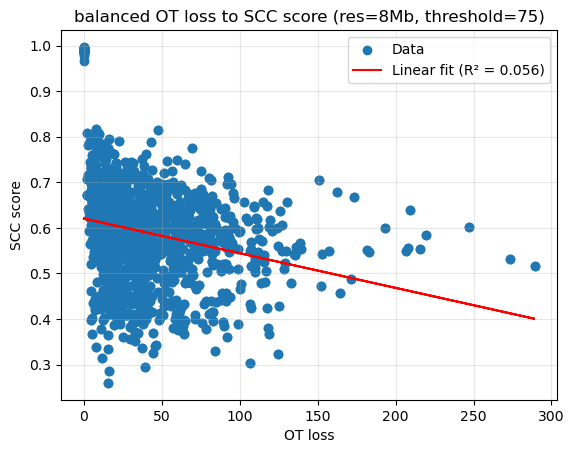

In [7]:
### 75 % Threshold ###
sc_scc_ot(8, 75, "CD4+ T cells", 50)

## 4 Mb

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

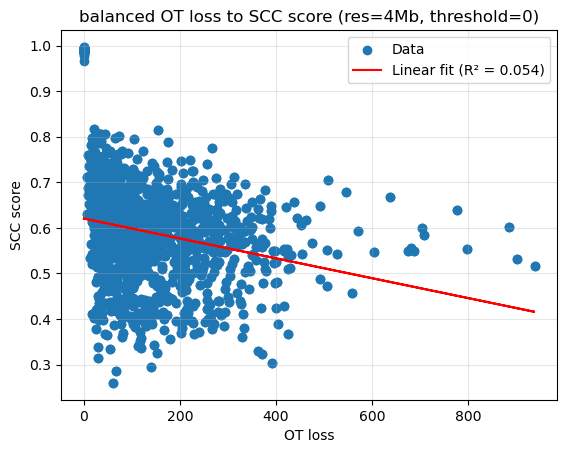

In [23]:
### 0 % Threshold ###
sc_scc_ot(4, 0, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

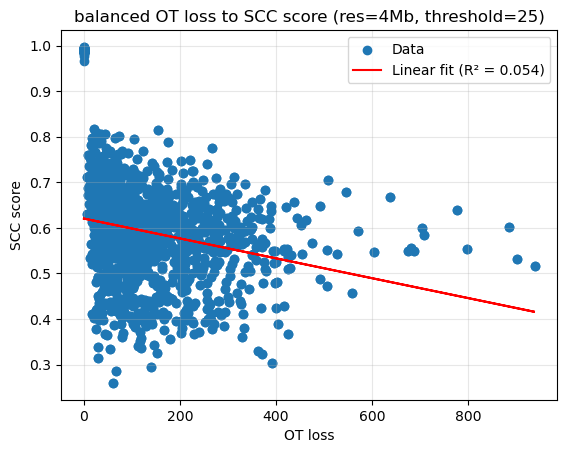

In [24]:
### 25 % Threshold ###
sc_scc_ot(4, 25, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

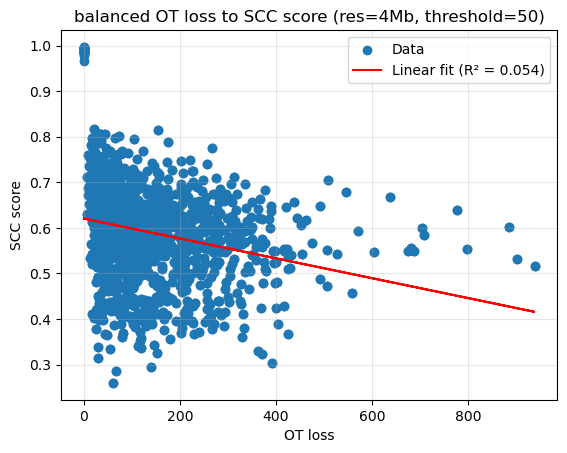

In [25]:
### 50 % Threshold ###
sc_scc_ot(4, 50, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

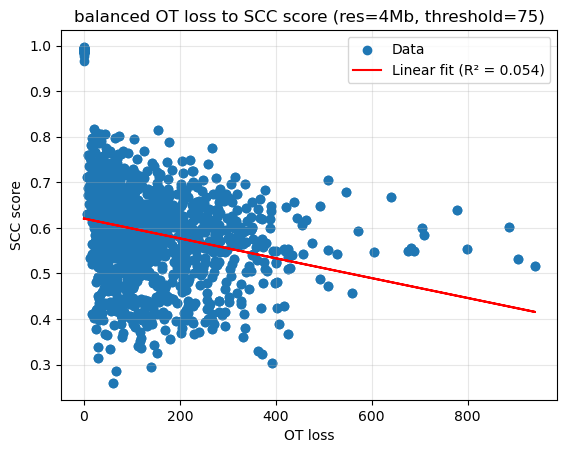

In [26]:
### 75 % Threshold ###
sc_scc_ot(4, 75, "CD4+ T cells", 50)

## 2 Mb

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

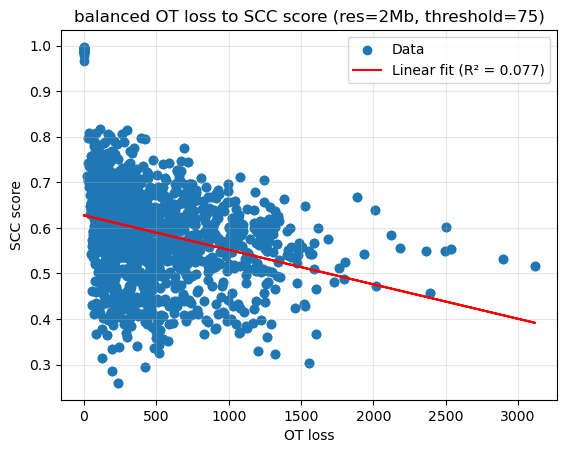

In [27]:
### 75 % Threshold ###
sc_scc_ot(2, 75, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

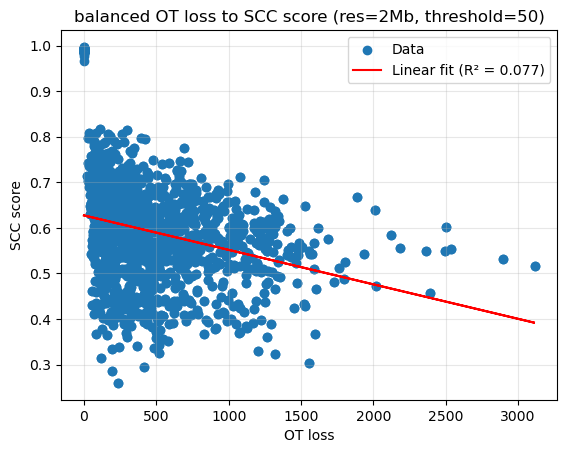

In [28]:
### 50 % Threshold ###
sc_scc_ot(2, 50, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

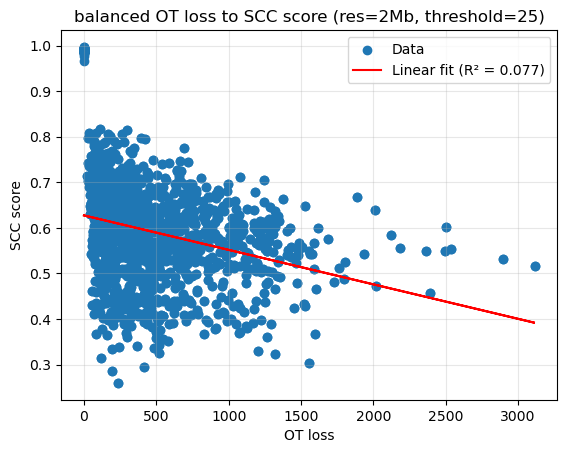

In [29]:
### 25 % Threshold ###
sc_scc_ot(2, 25, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

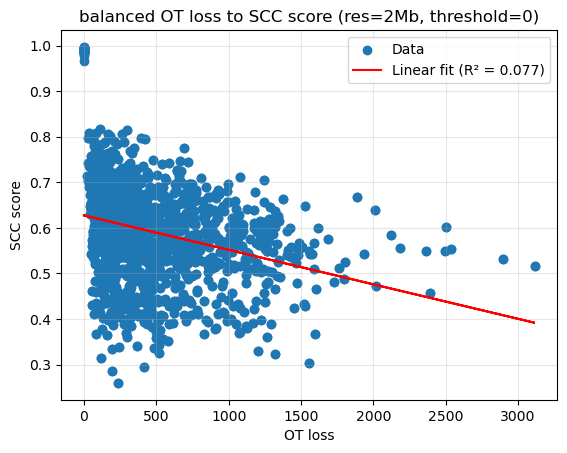

In [30]:
### 0 % Threshold ###
sc_scc_ot(2, 0, "CD4+ T cells", 50)

## 1 Mb

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

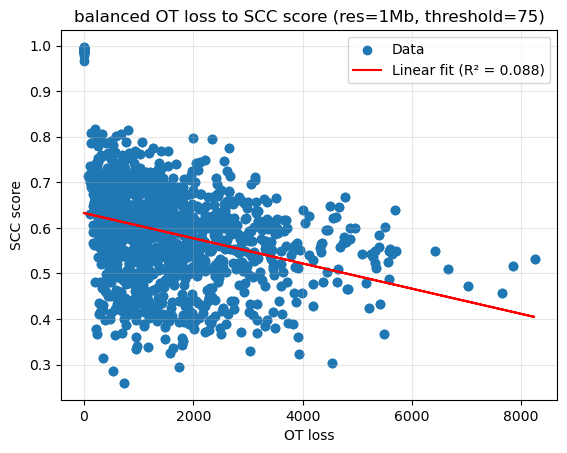

In [31]:
### 75 % Threshold ###
sc_scc_ot(1, 75, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

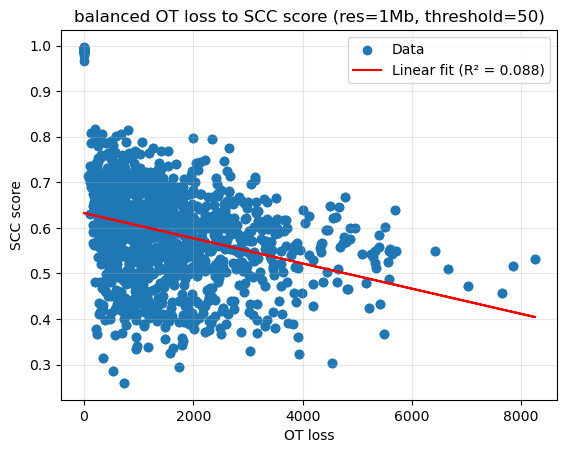

In [32]:
### 50 % Threshold ###
sc_scc_ot(1, 50, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

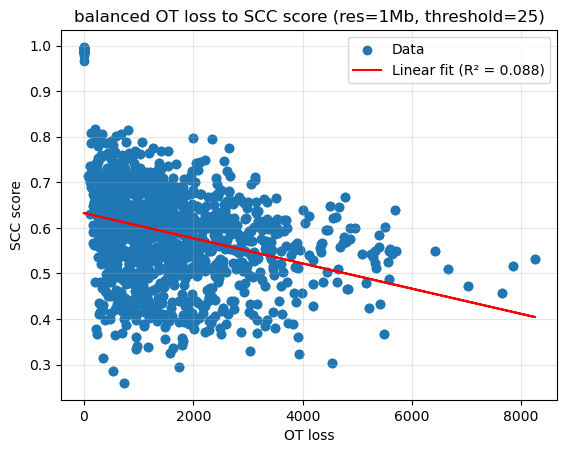

In [33]:
### 25 % Threshold ###
sc_scc_ot(1, 25, "CD4+ T cells", 50)

(                arc_pair_20032  arc_pair_5350  arc_pair_18299  arc_pair_4279  \
 arc_pair_20032        0.986961       0.614093        0.723393       0.699024   
 arc_pair_5350         0.614093       0.993461        0.490014       0.548480   
 arc_pair_18299        0.723393       0.490014        0.988256       0.806363   
 arc_pair_4279         0.699024       0.548480        0.806363       0.992013   
 arc_pair_18           0.716759       0.614719        0.645689       0.648162   
 arc_pair_12155        0.725753       0.579050        0.570498       0.586935   
 arc_pair_17547        0.638752       0.505735        0.577692       0.553561   
 arc_pair_5844         0.685090       0.606260        0.606801       0.616457   
 arc_pair_5055         0.654908       0.622654        0.561698       0.574881   
 arc_pair_11919        0.540662       0.425489        0.511747       0.491338   
 arc_pair_10963        0.693695       0.592822        0.684084       0.688739   
 arc_pair_16989        0.741

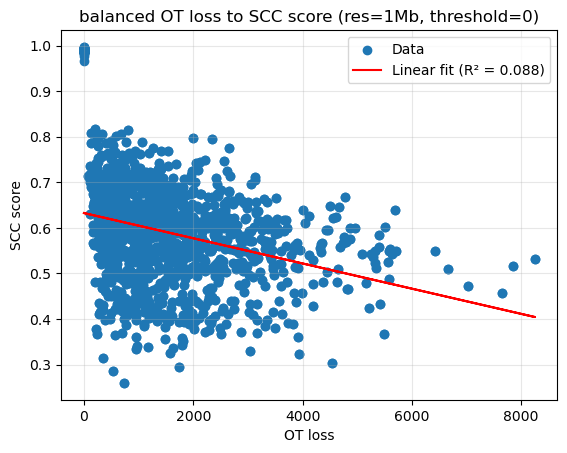

In [34]:
### 0 % Threshold ###
sc_scc_ot(1, 0, "CD4+ T cells", 50)

## Graphs

Text(0.5, 1.0, 'R² Value of Exact OT to SCC at Different Resolutions')

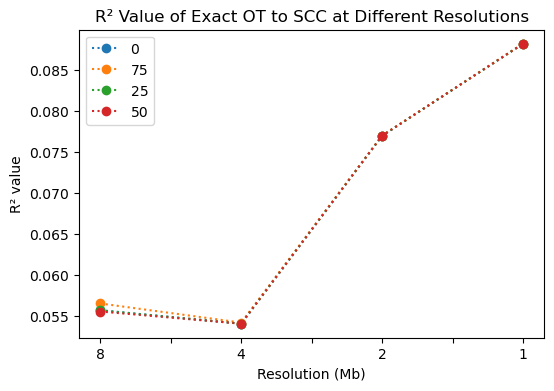

In [8]:
### R2 values ###
r2_file = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/exact_CD4+ T cells_50_r2.csv'
r2_df = pd.read_csv(r2_file, index_col=0)
r2_df.T.plot(figsize=(6, 4), marker='o', linestyle=":", linewidth=1.5)
plt.xlabel("Resolution (Mb)")
plt.ylabel("R\u00b2 value")
plt.title("R\u00b2 Value of Exact OT to SCC at Different Resolutions")

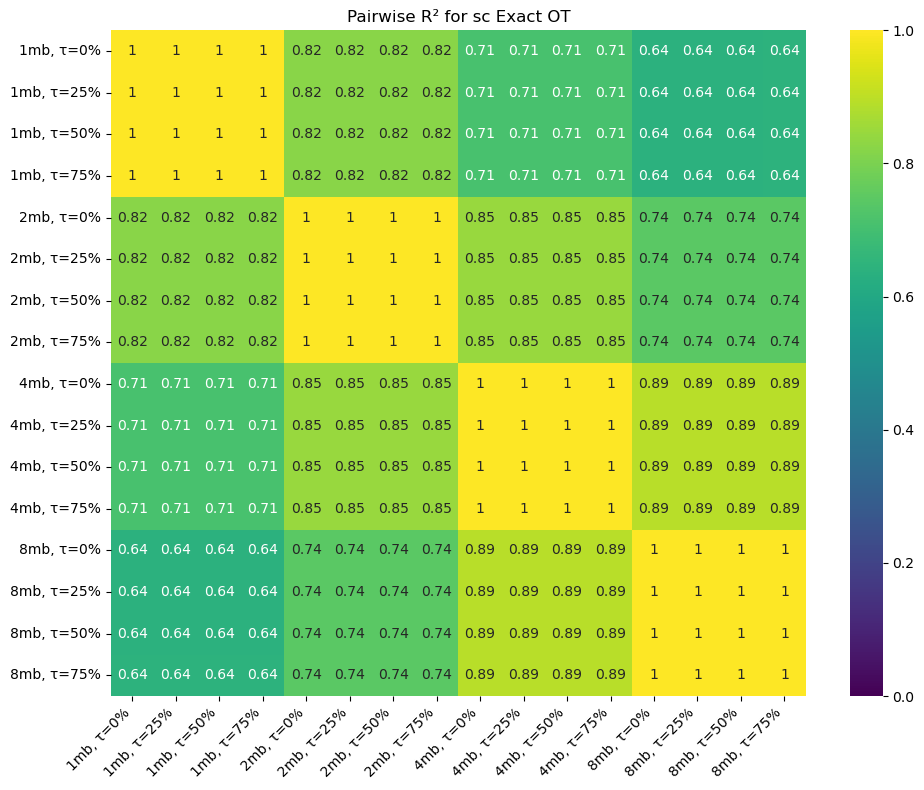

In [10]:
### Heatmap ###
    # Importing Data
ot_dfs = load_ot_results(save_ot_dir, "CD4+ T cells", 50)

    # Vectorizing matrices
ot_vectors = {}

for key, df in ot_dfs.items():
    vec = df.stack()
    ot_vectors[key] = vec

ot_vector_df = pd.DataFrame(ot_vectors)

    # Compute R2
ot_r2 = []
ot_cols = ot_vector_df.columns

for col1 in ot_cols:
    for col2 in ot_cols:
        x = ot_vector_df[col1].values
        y = ot_vector_df[col2].values
        regression = linregress(x, y)
        r2 = regression.rvalue ** 2
        ot_r2.append((col1, col2, r2))

ot_r2_df = pd.DataFrame(ot_r2, columns=["matrix_1", "matrix_2", "R²"])

    # Pivot to matrix form
ot_r2_matrix = ot_r2_df.pivot(index="matrix_1", columns="matrix_2", values="R²")

    # Making labels readable
def format_label(key):
    res, thr = key
    return f"{res}mb, τ={thr}%"

# Apply to index and columns
ot_r2_matrix.index = [format_label(k) for k in ot_r2_matrix.index]
ot_r2_matrix.columns = [format_label(k) for k in ot_r2_matrix.columns]


    # Plotting heatmap
plt.figure(figsize=(10,8))
sns.heatmap(ot_r2_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise R\u00b2 for sc Exact OT")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()